## Scenario 9 — Agentic AI for FSC Linear (efficient info)

- Framework: Multi-agent
- Decision making: **Gemini** (per-tier LLM calls), **strict JSON schema enforced**.
- Agents pick **discrete policy knobs** only: `alpha`, `service_level`, `expedite`.
- All inventory/forecast math remains **deterministic in code**.
- Linear forward chain.


In [ ]:
# ===== G2 — Setup =====
!pip -q install jsonschema google-generativeai

import os, json
from getpass import getpass

# 1) Read API key
if "GEMINI_API_KEY" not in os.environ or not os.environ["GEMINI_API_KEY"]:
    os.environ["GEMINI_API_KEY"] = getpass("Enter GEMINI_API_KEY: ")

# 2) Bypass any local proxies that may force localhost routing
for var in ["HTTP_PROXY","HTTPS_PROXY","ALL_PROXY","NO_PROXY","http_proxy","https_proxy","all_proxy","no_proxy"]:
    if var in os.environ:
        os.environ.pop(var, None)
# (Optional belt-and-suspenders)
os.environ["NO_PROXY"] = "*"

# 3) Configure client with explicit endpoint
import google.generativeai as genai
genai.configure(
    api_key=os.environ["GEMINI_API_KEY"],
    client_options={"api_endpoint": "https://generativelanguage.googleapis.com"}
)

# 4) Imports
import numpy as np
from dataclasses import dataclass
from typing import Dict, Any, List
from jsonschema import validate, ValidationError

# 5) Test
try:
    mdl = genai.GenerativeModel("gemini-1.5-flash")
    resp = mdl.generate_content("Return the single word: OK", request_options={"timeout": 6})
    print("Smoke test:", (resp.text or "").strip())
except Exception as e:
    print(" Test:", repr(e))

print("Setup complete.")


Enter GEMINI_API_KEY: ··········
Smoke test: OK
Setup complete.


In [ ]:
# ===== R1 — Roles, profiles, project, disruption, InfoBank (GLOBAL - NO DISTANCE WEIGHT) =====
from dataclasses import dataclass, field
from typing import Dict, Any, List, Optional
import numpy as np

rng = np.random.default_rng(42)
horizonWeeks = 52

# Project demand (units per span) for Steel
customerDemand = np.array([
    0, 4, 0, 0, 1, 3, 1, 1, 7, 1,
    1, 4, 9, 3, 5, 1, 2, 12, 1, 0,
    6, 1, 1, 1, 1, 1, 2, 1, 4, 2,
    7, 1, 0, 0, 1, 4, 5, 0, 2, 0,
    0, 1, 1, 1, 1, 0, 1, 0,
    0, 0, 0, 0
])

# ---- Supply chain structure (GC removed) ----
ROLES = ["Sub", "PO", "3PL", "Dist", "Sup"]
FLOW = {"Sup": "Dist", "Dist": "3PL", "3PL": "PO", "PO": "Sub"}

NEIGHBORS = {
  "Sub": ["PO"],
  "PO": ["Sub", "3PL"],
  "3PL": ["PO", "Dist"],
  "Dist": ["3PL", "Sup"],
  "Sup": ["Dist"]
}

@dataclass
class Profile:
  name: str
  policy_version: int = 0
  share_keys: List[str] = field(default_factory=list)

profiles: Dict[str, Profile] = {
  "Sub":  Profile("Sub", share_keys=["backlog"]),
  "PO":   Profile("PO", share_keys=["backlog", "pipeline"]),
  "3PL":  Profile("3PL", share_keys=["pipeline"]),
  "Dist": Profile("Dist", share_keys=["on_hand", "backlog"]),
  "Sup":  Profile("Sup", share_keys=["on_hand", "pipeline"]),
}

# Keep only used project info
project = {
  "id": "P1",
  "material": "Rebar#5",
}

disruption = {
  "week": 30,
  "delta_leadtime": 2,
  "duration_weeks": 8,
}

# Noise parameter (not used, set 0)
leadtime_noise = 0.0

def degrade_obs(x: float, rel_std: float, rng) -> float:
  return float(max(0.0, x * (1.0 + rng.normal(0.0, rel_std))))

class InfoBank:
  def __init__(self, profiles: Dict[str, Profile], rng, info_regime: str = "global"):
      if info_regime not in ["local", "global"]:
          raise ValueError("info_regime must be 'local' or 'global'")
      self.profiles = profiles
      self.rng = rng
      self.info_regime = info_regime
      self.local: Dict[str, Dict[str, Any]] = {r: {} for r in ROLES}

      # Key fix: shared data structure depends on regime
      if info_regime == "local":
          # Each role maintains separate shared views for each neighbor
          self.shared: Dict[str, Dict[str, Dict[str, Any]]] = {
              role: {neighbor: {} for neighbor in NEIGHBORS.get(role, [])}
              for role in ROLES
          }
      else:
          # Global regime: everyone can see everyone's shared data
          self.shared: Dict[str, Dict[str, Any]] = {r: {} for r in ROLES}

      self.true_lead: Dict[str, int] = {
          "Sup->Dist": 3,
          "Dist->3PL": 1,
          "3PL->PO": 1,
          "PO->Sub": 0
      }
      self.time = 0

  def apply_disruption(self, t: int):
      if t == disruption["week"]:
          self.true_lead["Sup->Dist"] += disruption["delta_leadtime"]
      if t == disruption["week"] + disruption["duration_weeks"]:
          self.true_lead["Sup->Dist"] -= disruption["delta_leadtime"]

  def update_share_policy(self, role: str, add_keys: Optional[List[str]] = None, drop_keys: Optional[List[str]] = None):
      p = self.profiles[role]
      if add_keys:
          for k in add_keys:
              if k not in p.share_keys and k in ["on_hand", "backlog", "pipeline"]:
                  p.share_keys.append(k)
      if drop_keys:
          p.share_keys = [k for k in p.share_keys if k not in drop_keys]
      p.policy_version += 1

  def publish(self, role: str):
      """Publish information according to the information regime"""
      policy_keys = set(self.profiles[role].share_keys)
      shared_data = {k: self.local[role].get(k) for k in policy_keys if k in self.local[role]}

      if self.info_regime == "local":
          # Only share with direct neighbors
          neighbors = NEIGHBORS.get(role, [])
          for neighbor in neighbors:
              # Each neighbor gets a copy of this role's shared data
              if neighbor in ROLES:
                  if neighbor not in self.shared:
                      self.shared[neighbor] = {}
                  self.shared[neighbor][role] = shared_data.copy()
      else:
          # Global regime: everyone can see this role's data
          self.shared[role] = shared_data.copy()

  def context_view_for(self, role: str) -> Dict[str, Any]:
      view = {
          "role": role,
          "t": self.time,
          "project_id": project["id"],
          "material": project["material"]
      }
      view[f"{role}_self"] = {k: self.local[role].get(k) for k in self.local[role].keys()}

      if self.info_regime == "local":
          # Can only see data from direct neighbors
          visible_roles = NEIGHBORS.get(role, [])
          for neighbor_role in visible_roles:
              # Get what this neighbor has shared with us
              neighbor_shared_data = self.shared.get(role, {}).get(neighbor_role, {})
              view[f"{neighbor_role}_shared"] = neighbor_shared_data
      else:
          # Global regime: can see everyone's shared data
          visible_roles = [r for r in ROLES if r != role]
          for r in visible_roles:
              view[f"{r}_shared"] = self.shared.get(r, {}).copy()

      view["my_profile"] = {
          "policy_version": self.profiles[role].policy_version
      }
      view["info_regime_context"] = {
          "regime": self.info_regime,
          "visible_roles": visible_roles,
          "total_network_size": len(ROLES)
      }
      return view

  def _get_shared_insights(self, role: str) -> Dict[str, float]:
      """Get aggregated insights from shared information"""
      downstream_backlog = 0.0
      upstream_inventory = 0.0
      visible_partners = []

      chain_order = {"Sup": 0, "Dist": 1, "3PL": 2, "PO": 3, "Sub": 4}
      my_position = chain_order.get(role, 2)

      if self.info_regime == "local":
          # Only process data from direct neighbors
          neighbors = NEIGHBORS.get(role, [])
          for neighbor_role in neighbors:
              shared_data = self.shared.get(role, {}).get(neighbor_role, {})
              if shared_data:
                  visible_partners.append(neighbor_role)
                  partner_position = chain_order.get(neighbor_role, 2)

                  # Downstream backlog (roles closer to customer)
                  if partner_position > my_position and "backlog" in shared_data:
                      downstream_backlog += float(shared_data["backlog"])

                  # Upstream inventory (roles closer to supplier)
                  if partner_position < my_position and "on_hand" in shared_data:
                      upstream_inventory += float(shared_data["on_hand"])
      else:
          # Global regime: no distance weighting - equal access to all roles
          visible_roles = [r for r in ROLES if r != role]
          for visible_role in visible_roles:
              shared_data = self.shared.get(visible_role, {})
              if shared_data:
                  visible_partners.append(visible_role)
                  partner_position = chain_order.get(visible_role, 2)

                  # Downstream backlog (roles closer to customer)
                  if partner_position > my_position and "backlog" in shared_data:
                      downstream_backlog += float(shared_data["backlog"])

                  # Upstream inventory (roles closer to supplier)
                  if partner_position < my_position and "on_hand" in shared_data:
                      upstream_inventory += float(shared_data["on_hand"])

      num_partners = len(visible_partners)
      if self.info_regime == "global" and num_partners > 0:
          downstream_backlog = downstream_backlog / num_partners
          upstream_inventory = upstream_inventory / num_partners

      return {
         "downstream_backlog": downstream_backlog,
         "upstream_inventory": upstream_inventory,
         "visible_partners": num_partners
      }

  def math_signals_for(self, role: str, hist: Dict[str, Dict[str, np.ndarray]], window: int = 8) -> Dict[str, Any]:
      t = self.time

      if role == "Sub":
          downstream_orders = np.asarray(customerDemand, dtype=float)
      elif role == "PO":
          if "orders_out" in hist and "Sub" in hist["orders_out"]:
              downstream_orders = np.asarray(hist["orders_out"]["Sub"], dtype=float)
          else:
              downstream_orders = np.zeros_like(np.asarray(customerDemand, dtype=float))  # No info = no orders
      elif role == "3PL":
          if "orders_out" in hist and "PO" in hist["orders_out"]:
              po_orders = np.asarray(hist["orders_out"]["PO"], dtype=float)
              recent_orders = po_orders[max(0, t-8):t+1]
              recent_total = recent_orders.sum()
              downstream_orders = po_orders if recent_total > 0.8 else np.zeros_like(np.asarray(customerDemand, dtype=float))
          else:
              downstream_orders = np.zeros_like(np.asarray(customerDemand, dtype=float))  # No info = no orders
      elif role == "Dist":
          if "orders_out" in hist and "3PL" in hist["orders_out"]:
              tpl_orders = np.asarray(hist["orders_out"]["3PL"], dtype=float)
              recent_orders = tpl_orders[max(0, t-8):t+1]
              recent_total = recent_orders.sum()
              downstream_orders = tpl_orders if recent_total > 1.0 else np.zeros_like(np.asarray(customerDemand, dtype=float))
          else:
              downstream_orders = np.zeros_like(np.asarray(customerDemand, dtype=float))  # No info = no orders
      elif role == "Sup":
          if "orders_out" in hist and "Dist" in hist["orders_out"]:
              dist_orders = np.asarray(hist["orders_out"]["Dist"], dtype=float)
              recent_orders = dist_orders[max(0, t-8):t+1]
              recent_total = recent_orders.sum()
              downstream_orders = dist_orders if recent_total > 0.5 else np.zeros_like(np.asarray(customerDemand, dtype=float))
          else:
              downstream_orders = np.zeros_like(np.asarray(customerDemand, dtype=float))  # No info = no orders
      else:
          downstream_orders = np.zeros_like(np.asarray(customerDemand, dtype=float))

      # Calculate demand statistics
      win = downstream_orders[max(0, t-window):t+1]
      dmean = float(win.mean()) if win.size else 0.0
      dstd = float(win.std(ddof=0)) if win.size else 0.0

      # Get shared insights and adjust demand estimate
      shared_insights = self._get_shared_insights(role)

      # Global info sharing = direct access to project schedule
      if self.info_regime == "global":
          # See actual project demand instead of distorted order patterns
          schedule_window = customerDemand[max(0, t-window):min(len(customerDemand), t+8)]
          if len(schedule_window) > 0:
              dmean = float(schedule_window[:window+1].mean())
              dstd = float(schedule_window[:window+1].std())

      # Perfect visibility of own inventory position
      inv = float(self.local[role].get("on_hand", 0.0))
      bkl = float(self.local[role].get("backlog", 0.0))
      pip = float(self.local[role].get("pipeline", 0.0))
      invpos_obs = inv + pip - bkl

      # Lead time estimation
      link = {
          "PO": "3PL->PO",
          "3PL": "Dist->3PL",
          "Dist": "Sup->Dist",
          "Sub": "PO->Sub"
      }.get(role, None)
      if link is None:
          L_obs = 0.0
      else:
          L_true = self.true_lead[link]
          L_obs = degrade_obs(L_true, leadtime_noise, self.rng)

      return {
          "t": t,
          "downstream_mean_obs": dmean,
          "downstream_std_obs": dstd,
          "inventory_position_obs": invpos_obs,
          "lead_time_obs": float(L_obs),
          "shared_visibility": shared_insights["visible_partners"],
          "info_regime": self.info_regime,
          # pass through the raw insight values too
          "upstream_inventory_signal": shared_insights["upstream_inventory"],
          "downstream_backlog_signal": shared_insights["downstream_backlog"],
      }

  def view_for_agent(self, role: str, hist: Dict[str, Dict[str, np.ndarray]], window: int = 8) -> Dict[str, Any]:
      return {
          "context_view": self.context_view_for(role),
          "math_signals": self.math_signals_for(role, hist, window),
      }

In [ ]:
# ===== R2 — Cleaned LLM Agent Decision Making =====
import json
from typing import Dict, Any, List
import math
import time
import numpy as np
import google.generativeai as genai

# ----------------------------
# Valid information sharing keys
# ----------------------------
allowed_share_keys = {"on_hand", "backlog", "pipeline"}

# ----------------------------
# Fixed LLM model without problematic schema constraint
# ----------------------------
gemini_coeff_fixed = genai.GenerativeModel(
    model_name="gemini-1.5-flash",
    generation_config=genai.GenerationConfig(
        temperature=0.4,
        response_mime_type="application/json"
    ),
    system_instruction=(
        "You are a role-bound decision maker in a multi-agent construction supply chain simulation. "
        "Always output valid JSON with numeric values within the specified ranges. "
        "No prose, only JSON."
    ),
)

REQUIRED_KEYS = {"alpha", "service_level", "lot_multiplier", "expedite", "share_add", "share_drop"}

# ----------------------------
# Validation
# ----------------------------
def validate_coeffs(obj: Dict[str, Any]) -> Dict[str, Any]:
    obj = {**{"share_add": [], "share_drop": []}, **obj}

    # Enforce exact key set
    keys = set(obj.keys())
    missing = {"alpha","service_level","lot_multiplier","expedite"} - keys
    extras = keys - REQUIRED_KEYS
    if missing:
        raise ValueError(f"Missing required keys: {sorted(missing)}")
    if extras:
        raise ValueError(f"Extra keys not allowed: {sorted(extras)}")

    # Type & domain checks
    if not isinstance(obj["alpha"], (int, float)) or not (0.05 <= obj["alpha"] <= 0.50):
        raise ValueError(f"alpha {obj['alpha']} must be a number in [0.05, 0.50]")
    if not isinstance(obj["service_level"], (int, float)) or not (0.80 <= obj["service_level"] <= 0.95):
        raise ValueError(f"service_level {obj['service_level']} must be a number in [0.80, 0.95]")
    if not isinstance(obj["lot_multiplier"], (int, float)) or not (0.50 <= obj["lot_multiplier"] <= 2.00):
        raise ValueError(f"lot_multiplier {obj['lot_multiplier']} must be a number in [0.50, 2.00]")
    if not isinstance(obj["expedite"], bool):
        raise ValueError(f"expedite {obj['expedite']} must be true or false")

    # Validate sharing keys
    for k in ("share_add", "share_drop"):
        if not isinstance(obj[k], list):
            raise ValueError(f"{k} must be a list")
        bad = [x for x in obj[k] if x not in allowed_share_keys]
        if bad:
            raise ValueError(f"{k} contains invalid keys: {bad}")

    # Round to two decimals for cleanliness
    obj["alpha"] = round(float(obj["alpha"]), 2)
    obj["service_level"] = round(float(obj["service_level"]), 2)
    obj["lot_multiplier"] = round(float(obj["lot_multiplier"]), 2)
    return obj

# ----------------------------
# Role strategies (qualitative — no numeric hints)
# ----------------------------
DEFAULT_STRATEGY = {
    "position": "Supply-chain agent",
    "key_pressure": "Balance service reliability with operational efficiency",
    "inventory_reality": "Finite capacity and budget constraints",
    "optimal_strategy": "Stabilize flow while reacting to material signals and disruptions",
    "decision_drivers": "Use observed volatility, cover, backlog, and lead-time signals"
}

ROLE_STRATEGIES = {
    "Sub": {
        "position": "End consumer: directly faces project demand",
        "key_pressure": "Crew idle time is highly costly; stockouts cause immediate work stoppage",
        "inventory_reality": "Very limited on-site storage; frequent deliveries are necessary",
        "optimal_strategy": "Maintain high responsiveness to demand changes while avoiding overstock; prefer smaller, more frequent orders",
        "decision_drivers": "React quickly to schedule changes and minimize storage-related risk"
    },
    "PO": {
        "position": "Specialized procurement function: natural broker",
        "key_pressure": "Bridge between design specs and supplier capabilities despite limited authority",
        "inventory_reality": "Minimal direct inventory control; focused on specification and sourcing",
        "optimal_strategy": "Leverage brokerage position to coordinate early supplier engagement while working within limited organizational mandate",
        "decision_drivers": "Navigate structural holes between production, oversight, and execution while building case for expanded coordination role"
    },
    "3PL": {
        "position": "Material consolidation yard: aggregates shipments and manages delivery timing",
        "key_pressure": "Consolidation efficiency versus delivery responsiveness; balancing batch economies with urgency",
        "inventory_reality": "Short-term staging for consolidation; costs rise with holding time but efficiency improves with larger batches",
        "optimal_strategy": "Balance quick response to urgent orders against waiting to consolidate efficient full loads; smooth irregular upstream deliveries into steady downstream flow",
        "decision_drivers": "Trade off immediate delivery against consolidation savings; manage variability between lumpy supplier deliveries and steady customer needs"
    },
    "Dist": {
        "position": "Regional warehouse: serves multiple customers and buffers variability",
        "key_pressure": "Significant holding costs versus reputational risk from service failures",
        "inventory_reality": "Large capacity but costly to maintain at high occupancy",
        "optimal_strategy": "Smooth variability, uphold high service reliability, and consolidate orders for efficiency",
        "decision_drivers": "Optimize storage efficiency while safeguarding customer retention"
    },
    "Sup": {
        "position": "Production facility: furthest upstream from end demand",
        "key_pressure": "High setup and holding costs; frequent changeovers reduce efficiency",
        "inventory_reality": "Capacity and scheduling constraints; efficiency improves with longer runs",
        "optimal_strategy": "Stabilize production with longer, consistent runs while keeping enough inventory to ensure downstream reliability",
        "decision_drivers": "Reduce changeovers, maintain production efficiency, and provide dependable supply"
    }
}



def _create_role_specific_prompt(role: str, view: Dict[str, Any]) -> str:
    """Create role-specific prompt that drives distinct behavior."""
    if role not in ROLE_STRATEGIES:
        raise ValueError(f"Unknown role '{role}'. Allowed roles: {list(ROLE_STRATEGIES.keys())}")

    math_signals = view["math_signals"]
    context = view["context_view"]
    week = math_signals["t"]

    # Current operational state
    my_state = context.get(f"{role}_self", {})
    backlog = float(my_state.get("backlog", 0.0))
    inventory = float(my_state.get("on_hand", 0.0))
    pipeline = float(my_state.get("pipeline", 0.0))

    # Observations
    demand_mean = float(math_signals.get("downstream_mean_obs", 0.0))
    demand_std  = float(math_signals.get("downstream_std_obs", 0.0))
    lead_time   = float(math_signals.get("lead_time_obs", 0.0))
    lead_time_ref = float(math_signals.get("lead_time_ref", lead_time))

    # Shared insights
    upstream_inventory = float(math_signals.get("upstream_inventory_signal", 0.0))
    downstream_backlog = float(math_signals.get("downstream_backlog_signal", 0.0))
    info_regime = math_signals.get("info_regime", "local")

    # Information regime
    visible_partners = {k: v for k, v in context.items() if k.endswith("_shared") and v}

    # Role-specific strategy (qualitative) — no fallback
    strategy = ROLE_STRATEGIES[role]

    # Disruption context
    disruption_note = ""
    if 30 <= week <= 38:
        disruption_note = "⚠️ SUPPLY DISRUPTION ACTIVE — lead times extended; reliability at risk"




    # Decision glossary + numeric domains (no role-specific hints)
    decision_glossary = f"""
Critical: All values must be in these exact ranges

Decision knobs (numeric):
- responsiveness (alpha) in [0.05, 0.50]
  Meaning: weight on recent demand signals vs. historical smoothing.
  Higher= reacts faster to changes; Lower= smooths noise and favors stability.
- service_level in [0.80, 0.95]
  Meaning: reliability target for avoiding stockout before replenishment.
  Higher= fewer stockouts but more inventory; Lower= leaner inventory with higher risk.
- lot_multiplier in [0.50, 2.00]
  Meaning: order/batch size relative to a nominal order.
  Higher= larger, less frequent orders (efficiency, less flexibility); Lower= smaller, more frequent orders (flexibility, more ordering overhead).
- expedite in {{true,false}}
  Meaning: pay a premium to shorten delay when stockout risk is material.
- share_add / share_drop are subsets of {sorted(list(allowed_share_keys))}
  Meaning: information you will start/stop sharing this week to improve coordination.

Constraints:
- Provide numeric values only (two decimals max) for alpha, service_level, and lot_multiplier.
- Stay within the ranges above; if you would go outside, choose the nearest bound.
- Base choices on this week's signals (volatility, cover, backlog, lead-time), not on assumptions.
"""

    # Final prompt
    prompt = f"""You are operating as: {strategy['position']} (week {week}).

{disruption_note or ""}

{decision_glossary}

Output (valid JSON only; no prose):
{{
  "alpha": <number>,
  "service_level": <number>,
  "lot_multiplier": <number>,
  "expedite": <true|false>,
  "share_add": <list of strings from allowed keys>,
  "share_drop": <list of strings from allowed keys>
}}"""

    return prompt

# ----------------------------
# LLM call with robust retries
# ----------------------------
def llm_choose_coeffs(role: str, view: Dict[str, Any]) -> Dict[str, Any]:
    """Call LLM with role-specific prompts; validate and return numeric coefficients."""
    prompt = _create_role_specific_prompt(role, view)

    last_err = None
    for attempt in range(5):  # More attempts for network issues
        try:
            # Add exponential backoff for network errors
            if attempt > 0:
                wait_time = min(30, (2 ** attempt) + np.random.uniform(0, 2))
                print(f"Retry {attempt} for {role}, waiting {wait_time:.1f}s...")
                time.sleep(wait_time)

            # Use the fixed model
            resp = gemini_coeff_fixed.generate_content([prompt])
            text = getattr(resp, "text", "") or ""

            # Clean the response (remove any markdown formatting)
            text = text.strip()
            if text.startswith("```json"):
                text = text[7:]
            if text.endswith("```"):
                text = text[:-3]
            text = text.strip()

            obj = json.loads(text)
            validated = validate_coeffs(obj)
            print(f"✅ {role} LLM success (attempt {attempt+1})")
            return validated

        except json.JSONDecodeError as e:
            print(f"❌ {role} JSON error: {text}")
            last_err = e
        except Exception as e:
            print(f"❌ {role} attempt {attempt+1} failed: {e}")
            last_err = e
            # Continue retrying for all errors

    # If all retries fail, this is a critical error
    print(f"CRITICAL: All LLM attempts failed for {role}: {last_err}")
    raise ValueError(f"LLM completely failed for {role} after all retries")

# Test the fixed model
print("Testing fixed LLM model...")
try:
    test_resp = gemini_coeff_fixed.generate_content([
        'Output this exact JSON: {"alpha": 0.25, "service_level": 0.85, "lot_multiplier": 1.0, "expedite": false, "share_add": [], "share_drop": []}'
    ])
    test_obj = json.loads(test_resp.text)
    print(f"✅ Fixed model test: {test_obj}")
    if 0.05 <= test_obj["alpha"] <= 0.50:
        print("✅ Constraints respected!")
    else:
        print("❌ Still ignoring constraints")
except Exception as e:
    print(f"❌ Fixed model still failing: {e}")


Testing fixed LLM model...
✅ Fixed model test: {'alpha': 0.25, 'service_level': 0.85, 'lot_multiplier': 1.0, 'expedite': False, 'share_add': [], 'share_drop': []}
✅ Constraints respected!


In [ ]:
# ===== R3 — Supply Chain Formulas =====
import numpy as np
from scipy import stats

def zFromServiceLevel(p: float) -> float:
    """
    Convert service level to z-score using inverse normal distribution.
    """
    if not (0.5 <= p <= 0.999):
        raise ValueError(f"Service level {p} must be between 0.5 and 0.999")
    return float(stats.norm.ppf(p))

def update_forecast(prev_forecast: float, signal_mean_obs: float, alpha: float) -> float:
    """Exponential smoothing driven by observed mean demand."""
    return alpha * signal_mean_obs + (1.0 - alpha) * prev_forecast

def base_stock_target(mu_hat: float, dstd_obs: float, L_obs: float, z: float) -> float:
    """
    Uses (L_obs + 1) convention (cycle + pipeline).
    """
    mean_LT = mu_hat * (L_obs + 1.0)
    std_LT  = dstd_obs * np.sqrt(max(0.0, L_obs + 1.0))
    return mean_LT + z * std_LT

def compute_order_qty(invpos_obs: float, target: float, lot_multiplier: float) -> float:
    """
    Gap-based ordering with a lot-size multiplier (agent-chosen).
    """
    gap = max(0.0, target - invpos_obs)
    return max(0.0, lot_multiplier * gap)

In [ ]:
# ===== R4 — Simulation Runner =====
from typing import Dict, Any
import numpy as np

def apply_realistic_constraints(role: str, raw_order_qty: float, ms: dict, t: int) -> float:
    """
    Apply realistic inventory constraints to prevent unrealistic ordering behavior
    """
    weekly_demand = max(1.0, ms["downstream_mean_obs"])
    current_inventory = ms["inventory_position_obs"]

    # Maximum inventory constraints by role
    if role == "Dist":
        max_inventory = weekly_demand * 3.0
    elif role == "Sup":
        max_inventory = weekly_demand * 4.0
    elif role == "3PL":
        max_inventory = weekly_demand * 2.0
    else:
        max_inventory = weekly_demand * 4.0

    # Maximum single order
    max_single_order = weekly_demand * 1.5

    if current_inventory > max_inventory:
        constrained_qty = 0.0
    else:
        # Limit order size to not exceed max inventory
        max_order_by_capacity = max(0.0, max_inventory - current_inventory)
        constrained_qty = min(raw_order_qty, max_single_order, max_order_by_capacity)

        # Force minimum ordering if inventory is getting low
        min_inventory_threshold = weekly_demand * 1.0
        if current_inventory < min_inventory_threshold and constrained_qty < weekly_demand * 0.5:
            forced_min = weekly_demand * 0.5
            constrained_qty = max(constrained_qty, forced_min)

    return constrained_qty

def run_construction_scenario(
    T: int,
    info_bank: InfoBank,
    rng,
    window: int = 8,
    sup_production_lead: int = 1,
):
    # Roles that actually make decisions
    ROLES_ACTIVE = [r for r in ROLES]

    # Time-series histories
    hist = {
        "on_hand":       {r: np.zeros(T, dtype=float) for r in ROLES},
        "backlog":       {r: np.zeros(T, dtype=float) for r in ROLES},
        "pipeline":      {r: np.zeros(T, dtype=float) for r in ROLES},
        "orders_in":     {r: np.zeros(T, dtype=float) for r in ROLES},
        "orders_out":    {r: np.zeros(T, dtype=float) for r in ROLES},
        "shipments_in":  {r: np.zeros(T, dtype=float) for r in ROLES},
        "shipments_out": {r: np.zeros(T, dtype=float) for r in ROLES},
    }

    # Arrival schedules
    arrivals = {r: np.zeros(T + 16, dtype=float) for r in ROLES}

    # Low starting inventory to force ordering
    for r in ROLES:
        if r == "Sub":
            info_bank.local[r]["on_hand"] = 5.0
        elif r == "PO":
            info_bank.local[r]["on_hand"] = 8.0
        elif r == "3PL":
            info_bank.local[r]["on_hand"] = 4.0
        elif r == "Dist":
            info_bank.local[r]["on_hand"] = 3.0
        elif r == "Sup":
            info_bank.local[r]["on_hand"] = 6.0
        else:
            # Any non-operational roles start at zero and won't place orders
            info_bank.local[r]["on_hand"] = 0.0

        info_bank.local[r]["backlog"] = 0.0
        info_bank.local[r]["pipeline"] = 0.0

    # Initialize history from InfoBank
    for r in ROLES:
        hist["on_hand"][r][0]  = float(info_bank.local[r]["on_hand"])
        hist["backlog"][r][0]  = float(info_bank.local[r]["backlog"])
        hist["pipeline"][r][0] = float(info_bank.local[r]["pipeline"])

    # Per-role forecasts
    forecast = {r: np.zeros(T, dtype=float) for r in ROLES}
    init_mean = customerDemand[:max(1, min(10, T))].mean()
    for r in ROLES:
        forecast[r][0] = init_mean

    # Coefficient logs
    coeff_logs: Dict[str, list[Dict[str, Any]]] = {r: [] for r in ROLES}

    # Pipeline trackers
    pipeline_now = {r: hist["pipeline"][r][0] for r in ROLES}

    for t in range(T):
        # Advance time and apply disruptions
        info_bank.time = t
        info_bank.apply_disruption(t)

        # Process arrivals
        for r in ROLES:
            a = float(arrivals[r][t])
            if a > 0:
                hist["shipments_in"][r][t] += a
                hist["on_hand"][r][t] += a
                pipeline_now[r] = max(0.0, pipeline_now[r] - a)

        # Calculate incoming orders
        for r in ROLES:
            if r == "Sub":
                demand_t = float(customerDemand[t])
            else:
                # Upstream receives orders from its immediate customer tier
                if r == "PO":
                    customer_role = "Sub"
                elif r == "3PL":
                    customer_role = "PO"
                elif r == "Dist":
                    customer_role = "3PL"
                elif r == "Sup":
                    customer_role = "Dist"
                else:
                    customer_role = None

                demand_t = float(hist["orders_out"][customer_role][t-1]) if (customer_role and t > 0) else 0.0

            hist["orders_in"][r][t] = demand_t

        # Process shipments and update backlog
        for r in ROLES:
            need = hist["backlog"][r][t] + hist["orders_in"][r][t]
            ship = min(hist["on_hand"][r][t], need)
            hist["shipments_out"][r][t] = ship
            hist["on_hand"][r][t] -= ship
            hist["backlog"][r][t] = need - ship

        # Sync InfoBank with current state
        for r in ROLES:
            info_bank.local[r]["on_hand"]  = float(hist["on_hand"][r][t])
            info_bank.local[r]["backlog"]  = float(hist["backlog"][r][t])
            info_bank.local[r]["pipeline"] = float(pipeline_now[r])

        # LLM decision making and ordering (only for active roles)
        for r in ROLES_ACTIVE:
            view = info_bank.view_for_agent(r, hist, window=window)
            coeffs = llm_choose_coeffs(r, view)
            coeff_logs[r].append({"t": t, **coeffs})

            # Apply sharing policy changes
            if coeffs.get("share_add") or coeffs.get("share_drop"):
                info_bank.update_share_policy(r, add_keys=coeffs.get("share_add"), drop_keys=coeffs.get("share_drop"))
            info_bank.publish(r)

            # Calculate order quantities
            if r == "Sub":
                q = max(0.0, customerDemand[t])
            else:
                ms = view["math_signals"]
                alpha = coeffs["alpha"]
                service_level = coeffs["service_level"]
                lot_mult = coeffs["lot_multiplier"]

                # Update forecast
                prev_f = forecast[r][t-1] if t > 0 else forecast[r][0]
                mu_hat = update_forecast(prev_f, ms["downstream_mean_obs"], alpha)
                forecast[r][t] = mu_hat

                # Cap service level and lot multiplier
                capped_service_level = min(service_level, 0.88)
                capped_lot_mult = min(lot_mult, 1.25)

                # Target and order
                z = zFromServiceLevel(capped_service_level)
                target = base_stock_target(mu_hat, ms["downstream_std_obs"], ms["lead_time_obs"], z)
                raw_q = compute_order_qty(ms["inventory_position_obs"], target, capped_lot_mult)

                # Apply constraints
                q = apply_realistic_constraints(r, raw_q, ms, t)

            # Expedite logic
            if bool(coeffs["expedite"]) and hist["backlog"][r][t] > 0:
                exp_now = min(q * 0.25, hist["backlog"][r][t])
                hist["shipments_in"][r][t] += exp_now
                hist["on_hand"][r][t] += exp_now

            hist["orders_out"][r][t] = q

            # Schedule production and shipments
            if r == "Sup":
                prod_lead = int(max(0, sup_production_lead))
                t_arr_sup = t + prod_lead
                if t_arr_sup < len(arrivals["Sup"]) and q > 0:
                    arrivals["Sup"][t_arr_sup] += q
                    pipeline_now["Sup"] += q

        # Schedule shipments to downstream (all roles)
        for r in ROLES:
            down = FLOW.get(r)
            if down is not None:
                link = f"{r}->{down}"
                L_ship = int(max(0, info_bank.true_lead.get(link, 0)))
                t_arr_down = t + L_ship
                ship_qty = float(hist["shipments_out"][r][t])
                if ship_qty > 0 and t_arr_down < len(arrivals[down]):
                    arrivals[down][t_arr_down] += ship_qty
                    pipeline_now[down] += ship_qty

        # Carry forward state to next period
        if t < T - 1:
            for r in ROLES:
                hist["on_hand"][r][t+1]  = hist["on_hand"][r][t]
                hist["backlog"][r][t+1]  = hist["backlog"][r][t]
                hist["pipeline"][r][t+1] = hist["pipeline"][r][t]

    return hist, forecast, coeff_logs, info_bank

# Initialize InfoBank and run simulation (GLOBAL)
info_bank = InfoBank(profiles=profiles, rng=rng, info_regime="global")

hist_roles, forecast_roles, coeff_logs, info_bank = run_construction_scenario(
    T=horizonWeeks,
    info_bank=info_bank,
    rng=rng,
    window=8,
    sup_production_lead=1,
)
print("Simulation complete.")


✅ Sub LLM success (attempt 1)
✅ PO LLM success (attempt 1)
✅ 3PL LLM success (attempt 1)
✅ Dist LLM success (attempt 1)
✅ Sup LLM success (attempt 1)
✅ Sub LLM success (attempt 1)
✅ PO LLM success (attempt 1)
✅ 3PL LLM success (attempt 1)
✅ Dist LLM success (attempt 1)
✅ Sup LLM success (attempt 1)
✅ Sub LLM success (attempt 1)
✅ PO LLM success (attempt 1)
✅ 3PL LLM success (attempt 1)
✅ Dist LLM success (attempt 1)
✅ Sup LLM success (attempt 1)
✅ Sub LLM success (attempt 1)
✅ PO LLM success (attempt 1)
✅ 3PL LLM success (attempt 1)
✅ Dist LLM success (attempt 1)
✅ Sup LLM success (attempt 1)
✅ Sub LLM success (attempt 1)
✅ PO LLM success (attempt 1)
✅ 3PL LLM success (attempt 1)
✅ Dist LLM success (attempt 1)
✅ Sup LLM success (attempt 1)
✅ Sub LLM success (attempt 1)
✅ PO LLM success (attempt 1)
✅ 3PL LLM success (attempt 1)
✅ Dist LLM success (attempt 1)
✅ Sup LLM success (attempt 1)
✅ Sub LLM success (attempt 1)
✅ PO LLM success (attempt 1)
✅ 3PL LLM success (attempt 1)
✅ Dist LLM 

ORDER ACTIVITY:
Sub : Total= 101.0, Active_weeks=37/52, Max=  12.0
PO  : Total=  97.1, Active_weeks=26/52, Max=   6.5
3PL : Total=  99.8, Active_weeks=25/52, Max=   6.5
Dist: Total= 106.8, Active_weeks=29/52, Max=   6.5
Sup : Total= 105.9, Active_weeks=28/52, Max=   6.5

WEEKLY ORDER PATTERNS:
 week  Sub_order  PO_order  3PL_order  Dist_order  Sup_order
    0        0.0       0.0        0.0         0.8        0.0
   10        1.0       2.5        2.5         0.6        0.0
   20        6.0       6.5        6.5         6.5        6.5
   30        7.0       0.0        0.0         3.3        3.3
   40        0.0       0.0        0.0         0.0        0.0
   50        0.0       0.0        0.0         0.0        0.0

INVENTORY ANALYSIS:

3PL:
  Week 20: on_hand=0.0, backlog=18.9, pipeline=0.0
  Week 20: inv_pos=-18.9
  Avg inventory (weeks 10-52): 5.1

Dist:
  Week 20: on_hand=0.0, backlog=16.3, pipeline=0.0
  Week 20: inv_pos=-16.3
  Avg inventory (weeks 10-52): 4.1

Sup:
  Week 20: on_ha

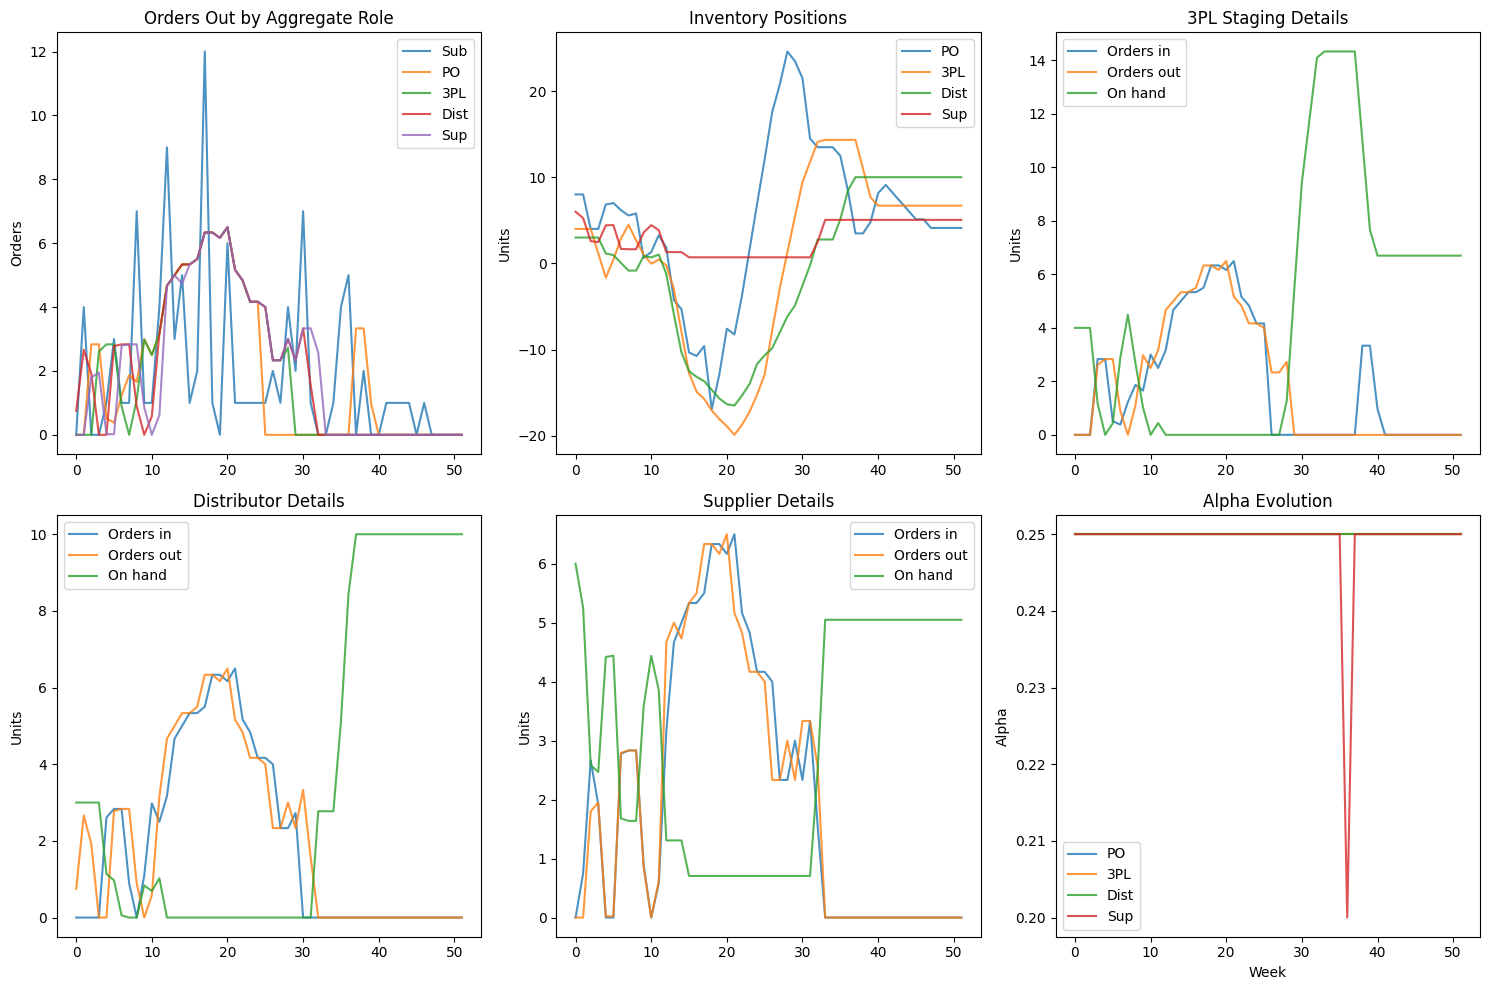

In [ ]:
# ===== Post-Run Diagnostics =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _keys(role_dict, prefix):
    return sorted([k for k in role_dict.keys() if k.startswith(prefix)])

if 'hist_roles' in globals() and 'coeff_logs' in globals():
    roles_present = set(hist_roles['orders_out'].keys())

    # Detect topology
    is_multi = any(r.startswith('Sub') and r != 'Sub' for r in roles_present) or \
               any(r.startswith('3PL_') for r in roles_present) or \
               any(r.startswith('Dist_') for r in roles_present)

    # Build canonical groups & series getters
    if is_multi:
        SUB_KEYS  = _keys(hist_roles['orders_out'], 'Sub')
        PO_KEYS   = _keys(hist_roles['orders_out'], 'PO')
        TPL_KEYS  = _keys(hist_roles['orders_out'], '3PL_')    # 3PL_A, 3PL_B
        DIST_KEYS = _keys(hist_roles['orders_out'], 'Dist_')   # Dist_A, Dist_B
        SUP_KEYS  = ['Sup'] if 'Sup' in roles_present else []

        def series_sum(field, keys):
            if not keys: return np.zeros_like(next(iter(hist_roles[field].values())))
            arrs = [hist_roles[field][k] for k in keys]
            return np.sum(arrs, axis=0)

        # Canonical aggregated labels → underlying keys
        AGG = {
            'Sub':  SUB_KEYS,
            'PO':   PO_KEYS,
            '3PL':  TPL_KEYS,
            'Dist': DIST_KEYS,
            'Sup':  SUP_KEYS,
        }

    else:
        # Single-chain names already match
        AGG = {r: [r] for r in ['Sub','PO','3PL','Dist','Sup'] if r in roles_present}

        def series_sum(field, keys):
            return sum((hist_roles[field][k] for k in keys))

    # ---------- ORDER ACTIVITY ----------
    print("ORDER ACTIVITY:")
    for label, keys in AGG.items():
        orders = series_sum('orders_out', keys)
        total_orders = float(orders.sum())
        non_zero_weeks = int((orders > 0.1).sum())
        max_order = float(orders.max()) if orders.size else 0.0
        print(f"{label:4s}: Total={total_orders:6.1f}, Active_weeks={non_zero_weeks:2d}/52, Max={max_order:6.1f}")

    # ---------- WEEKLY ORDER PATTERNS ----------
    print("\nWEEKLY ORDER PATTERNS:")
    weeks_to_check = [0,10,20,30,40,50]
    order_rows = []
    for t in weeks_to_check:
        row = {'week': t}
        for label, keys in AGG.items():
            row[f'{label}_order'] = series_sum('orders_out', keys)[t]
        order_rows.append(row)
    df_orders = pd.DataFrame(order_rows)
    print(df_orders.to_string(index=False, float_format=lambda x: f"{x:6.1f}"))

    # ---------- INVENTORY ANALYSIS (upstream roles only) ----------
    print("\nINVENTORY ANALYSIS:")
    for label in ['3PL','Dist','Sup']:
        if label not in AGG: continue
        on  = series_sum('on_hand',  AGG[label])
        bkl = series_sum('backlog',  AGG[label])
        pip = series_sum('pipeline', AGG[label])
        inv_pos = on + pip - bkl
        if on.size <= 20: continue
        print(f"\n{label}:")
        print(f"  Week 20: on_hand={on[20]:.1f}, backlog={bkl[20]:.1f}, pipeline={pip[20]:.1f}")
        print(f"  Week 20: inv_pos={inv_pos[20]:.1f}")
        print(f"  Avg inventory (weeks 10-52): {on[10:].mean():.1f}")

    # ---------- COEFFICIENT ANALYSIS ----------
    print("\nCOEFFICIENT ANALYSIS:")
    for label, keys in AGG.items():
        # merge coeff logs across keys (multi) or single key
        merged = []
        for k in keys:
            if k in coeff_logs:
                merged.extend(coeff_logs[k])
        if not merged:
            continue
        avg_alpha   = np.mean([c['alpha'] for c in merged])
        avg_service = np.mean([c['service_level'] for c in merged])
        avg_lot     = np.mean([c['lot_multiplier'] for c in merged])
        expedite_ct = int(sum(1 for c in merged if c['expedite']))
        print(f"{label}: alpha={avg_alpha:.2f}, service={avg_service:.2f}, lot={avg_lot:.2f}, expedites={expedite_ct}")

    # ---------- FLOW SNAPSHOT ----------
    print("\nSUPPLY CHAIN FLOW (aggregated):")
    flow_rows = []
    for t in [10,20,30,40]:
        row = {'week': t}
        for label, keys in AGG.items():
            row[f'{label}_in']  = series_sum('orders_in',  keys)[t]
            row[f'{label}_out'] = series_sum('orders_out', keys)[t]
        flow_rows.append(row)
    df_flow = pd.DataFrame(flow_rows)
    print(df_flow.to_string(index=False, float_format=lambda x: f"{x:6.1f}"))

    # ---------- PLOTS ----------
    plt.figure(figsize=(15,10))
    # Orders by aggregate role
    ax = plt.subplot(2,3,1)
    for label, keys in AGG.items():
        plt.plot(series_sum('orders_out', keys), label=label, alpha=0.8)
    ax.set_title("Orders Out by Aggregate Role"); ax.set_ylabel("Orders"); ax.legend()

    # Inventory positions (PO/3PL/Dist/Sup only)
    ax = plt.subplot(2,3,2)
    for label in ['PO','3PL','Dist','Sup']:
        if label not in AGG: continue
        inv_pos = (series_sum('on_hand', AGG[label]) +
                   series_sum('pipeline', AGG[label]) -
                   series_sum('backlog', AGG[label]))
        plt.plot(inv_pos, label=label, alpha=0.8)
    ax.set_title("Inventory Positions"); ax.set_ylabel("Units"); ax.legend()

    # 3PL details
    if '3PL' in AGG:
        ax = plt.subplot(2,3,3)
        plt.plot(series_sum('orders_in',  AGG['3PL']), label='Orders in',  alpha=0.8)
        plt.plot(series_sum('orders_out', AGG['3PL']), label='Orders out', alpha=0.8)
        plt.plot(series_sum('on_hand',    AGG['3PL']), label='On hand',    alpha=0.8)
        ax.set_title("3PL Staging Details"); ax.set_ylabel("Units"); ax.legend()

    # Dist details
    if 'Dist' in AGG:
        ax = plt.subplot(2,3,4)
        plt.plot(series_sum('orders_in',  AGG['Dist']), label='Orders in',  alpha=0.8)
        plt.plot(series_sum('orders_out', AGG['Dist']), label='Orders out', alpha=0.8)
        plt.plot(series_sum('on_hand',    AGG['Dist']), label='On hand',    alpha=0.8)
        ax.set_title("Distributor Details"); ax.set_ylabel("Units"); ax.legend()

    # Sup details
    if 'Sup' in AGG:
        ax = plt.subplot(2,3,5)
        plt.plot(series_sum('orders_in',  AGG['Sup']), label='Orders in',  alpha=0.8)
        plt.plot(series_sum('orders_out', AGG['Sup']), label='Orders out', alpha=0.8)
        plt.plot(series_sum('on_hand',    AGG['Sup']), label='On hand',    alpha=0.8)
        ax.set_title("Supplier Details"); ax.set_ylabel("Units"); ax.legend()

    # Alpha evolution
    ax = plt.subplot(2,3,6)
    for label in ['PO','3PL','Dist','Sup']:
        if label not in AGG: continue
        merged = []
        for k in AGG[label]:
            if k in coeff_logs: merged.extend(coeff_logs[k])
        if not merged: continue
        alphas = [c['alpha'] for c in merged]
        plt.plot(alphas, label=label, alpha=0.8)
    ax.set_title("Alpha Evolution"); ax.set_ylabel("Alpha"); ax.set_xlabel("Week"); ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Run the simulation first to generate hist_roles and coeff_logs data.")


Bullwhip metrics (post burn-in = 10):
role  bullwhip_ratio_var  amplification_std  mean_ratio
 3PL               0.882              0.939       1.043
Dist               0.850              0.922       1.110
  PO               0.896              0.947       0.998
 Sub               1.000              1.000       1.000
 Sup               0.838              0.915       1.117

Sample of coefficient choices:
role  t  alpha  service_level  lot_multiplier  expedite
 3PL  0   0.25            0.9             1.5     False
 3PL  1   0.25            0.9             1.5     False
 3PL  2   0.25            0.9             1.5     False
 3PL  3   0.25            0.9             1.5     False
 3PL  4   0.25            0.9             1.5     False
 3PL  5   0.25            0.9             1.0     False
 3PL  6   0.25            0.9             1.5     False
 3PL  7   0.25            0.9             1.5     False
 3PL  8   0.25            0.9             1.0     False
 3PL  9   0.25            0.9     

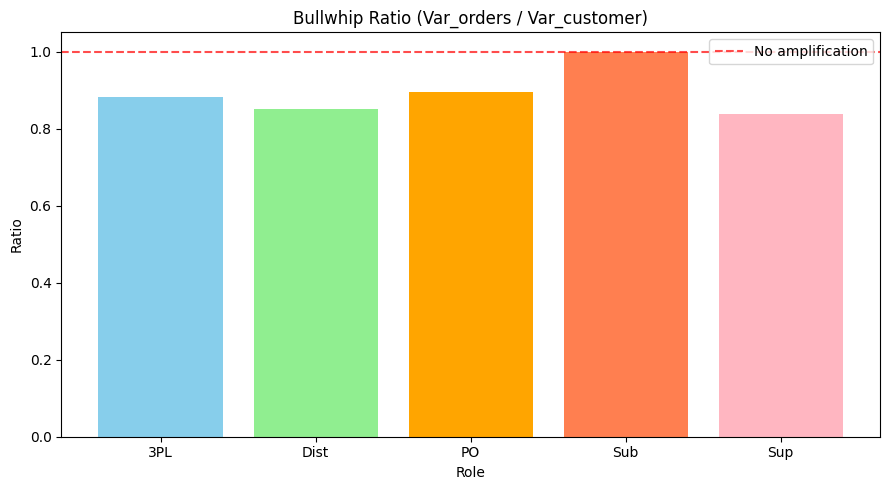

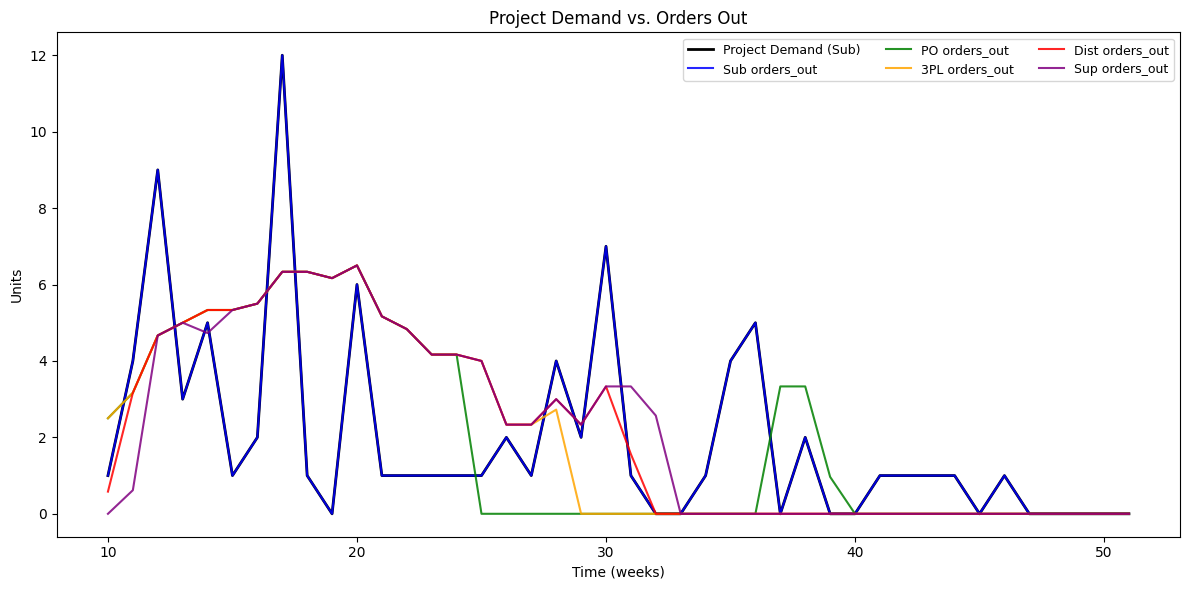

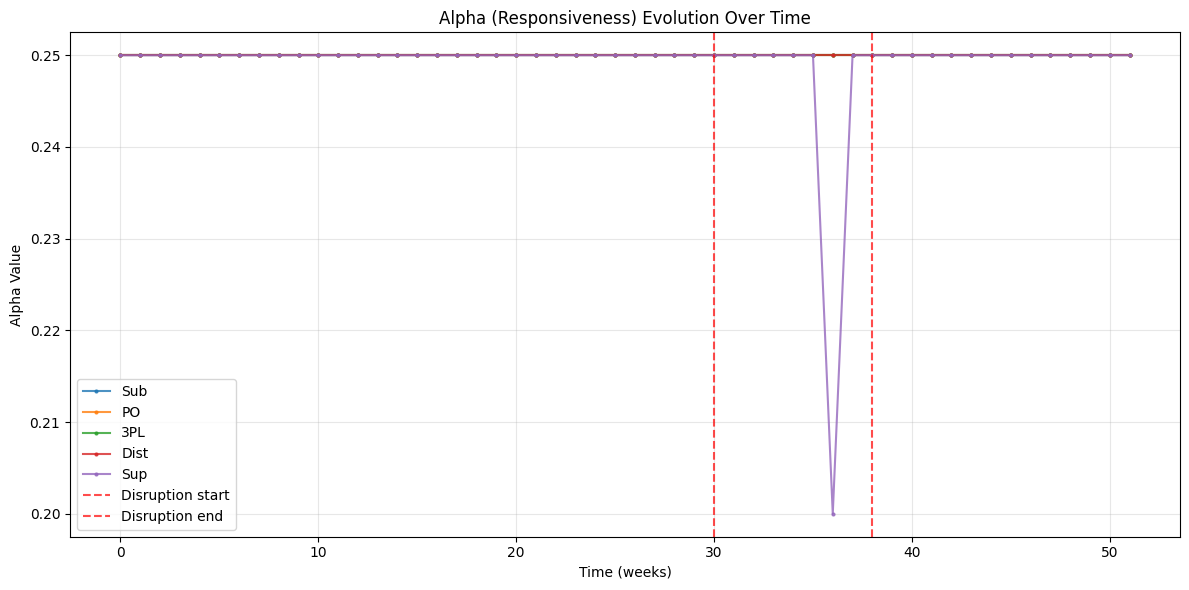

In [ ]:
# ===== R5 — KPIs + coefficient & sharing summaries =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define burn-in period to exclude initial startup effects
burnIn = 10  # exclude first 10 weeks from analysis

roles_holding = [r for r in ROLES]

def compute_metrics_roles(hist, demand, roles, burnIn=0):
   rows = []
   cust = np.asarray(demand[burnIn:], dtype=float)
   var_cust = float(np.var(cust, ddof=0))
   std_cust = float(np.std(cust, ddof=0))
   mean_cust = float(np.mean(cust))

   for r in roles:
       orders = np.asarray(hist["orders_out"][r][burnIn:], dtype=float)
       var_orders = float(np.var(orders, ddof=0))
       std_orders = float(np.std(orders, ddof=0))
       mean_orders = float(np.mean(orders))

       rows.append({
           "role": r,
           "bullwhip_ratio_var": (var_orders / var_cust) if var_cust > 0 else np.nan,
           "amplification_std": (std_orders / std_cust) if std_cust > 0 else np.nan,
           "mean_ratio": (mean_orders / mean_cust) if mean_cust > 0 else np.nan,
       })
   return pd.DataFrame(rows).sort_values("role")

# ---- KPIs
df_kpi = compute_metrics_roles(hist_roles, customerDemand, roles_holding, burnIn=burnIn)
print(f"Bullwhip metrics (post burn-in = {burnIn}):")
print(df_kpi.to_string(index=False, float_format=lambda x: f"{x:0.3f}"))

# ---- Coefficient logs
rows = []
for r, logs in coeff_logs.items():
   for rec in logs:
       rows.append({"role": r, **{k: rec.get(k) for k in ("t","alpha","service_level","lot_multiplier","expedite")}})
coeff_df = pd.DataFrame(rows).sort_values(["role","t"])
print("\nSample of coefficient choices:")
print(coeff_df.head(12).to_string(index=False))

# Distributions by role
alpha_dist = coeff_df.groupby(["role","alpha"]).size().rename("count").reset_index()
sl_dist    = coeff_df.groupby(["role","service_level"]).size().rename("count").reset_index()
lot_dist   = coeff_df.groupby(["role","lot_multiplier"]).size().rename("count").reset_index()
exp_dist   = coeff_df.groupby(["role","expedite"]).size().rename("count").reset_index()

print("\nAlpha choices (counts):")
print(alpha_dist.pivot(index="role", columns="alpha", values="count").fillna(0).astype(int))
print("\nService level choices (counts):")
print(sl_dist.pivot(index="role", columns="service_level", values="count").fillna(0).astype(int))
print("\nLot multiplier choices (counts):")
print(lot_dist.pivot(index="role", columns="lot_multiplier", values="count").fillna(0).astype(int))
print("\nExpedite choices (counts):")
print(exp_dist.pivot(index="role", columns="expedite", values="count").fillna(0).astype(int))

# ---- Sharing policy changes summary
policy_rows = []
for r, logs in coeff_logs.items():
   add_total = sum(len(rec.get("share_add", [])) for rec in logs)
   drop_total = sum(len(rec.get("share_drop", [])) for rec in logs)
   policy_rows.append({"role": r, "share_add_total": add_total, "share_drop_total": drop_total})
df_policy = pd.DataFrame(policy_rows).sort_values("role")
print("\nSharing policy changes (totals over run):")
print(df_policy.to_string(index=False))

# Current published keys by role (from InfoBank policies)
current_share = {r: profiles[r].share_keys for r in ROLES}
print("\nCurrent share policy keys by role:")
for r in ROLES:
   print(f"  {r}: {current_share[r]}")

# ---- Enhanced Analysis for 6-role chain
print("\n=== 6-ECHELON CHAIN ANALYSIS ===")

# Role-specific coefficient averages
print("\nAverage coefficients by role:")
role_avg_coeffs = coeff_df.groupby("role")[["alpha", "service_level", "lot_multiplier"]].mean()
print(role_avg_coeffs.round(3))

# Expedite frequency by role
print("\nExpedite frequency by role:")
expedite_freq = coeff_df.groupby("role")["expedite"].mean()
print(expedite_freq.round(3))

# Pre-crisis vs Crisis vs Post-crisis comparison
periods = {
   "pre_crisis": (0, 30),
   "crisis": (30, 38),
   "post_crisis": (38, 52)
}

print("\nPeriod-based coefficient analysis:")
for period_name, (start, end) in periods.items():
   period_data = coeff_df[(coeff_df["t"] >= start) & (coeff_df["t"] < end)]
   if len(period_data) > 0:
       print(f"\n{period_name.upper()}:")
       period_avg = period_data.groupby("role")[["alpha", "service_level", "lot_multiplier"]].mean()
       print(period_avg.round(3))

# ---- Plots
# 1) Bullwhip ratio bar
plt.figure(figsize=(9,5))
plt.bar(df_kpi["role"], df_kpi["bullwhip_ratio_var"], color=['skyblue', 'lightgreen', 'orange', 'coral', 'lightpink'])
plt.axhline(1.0, linestyle="--", color='red', alpha=0.7, label='No amplification')
plt.title("Bullwhip Ratio (Var_orders / Var_customer)")
plt.ylabel("Ratio"); plt.xlabel("Role")
plt.legend(); plt.tight_layout(); plt.show()

# 2) Orders_out vs. customer demand (post burn-in)
t_idx = np.arange(len(customerDemand))
plt.figure(figsize=(12,6))
plt.plot(t_idx[burnIn:], customerDemand[burnIn:], label="Project Demand (Sub)", linewidth=2, color='black')
colors = ['blue', 'green', 'orange', 'red', 'purple']
for i, r in enumerate(roles_holding):
   plt.plot(t_idx[burnIn:], hist_roles["orders_out"][r][burnIn:],
            label=f"{r} orders_out", alpha=0.85, color=colors[i])
plt.title("Project Demand vs. Orders Out")
plt.xlabel("Time (weeks)"); plt.ylabel("Units")
plt.legend(ncol=3, fontsize=9); plt.tight_layout(); plt.show()

# 3) New: Alpha evolution by role
plt.figure(figsize=(12,6))
for r in roles_holding:
   if r in coeff_logs:
       times = [rec["t"] for rec in coeff_logs[r]]
       alphas = [rec["alpha"] for rec in coeff_logs[r]]
       plt.plot(times, alphas, label=f"{r}", marker='o', markersize=2, alpha=0.8)

plt.axvline(x=30, color='red', linestyle='--', alpha=0.7, label='Disruption start')
plt.axvline(x=38, color='red', linestyle='--', alpha=0.7, label='Disruption end')
plt.title("Alpha (Responsiveness) Evolution Over Time")
plt.xlabel("Time (weeks)"); plt.ylabel("Alpha Value")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ---- Optional: save summaries
# coeff_df.to_csv("coeff_choices_6role.csv", index=False)
# df_kpi.to_csv("kpi_bullwhip_6role.csv", index=False)
# df_policy.to_csv("sharing_changes_6role.csv", index=False)

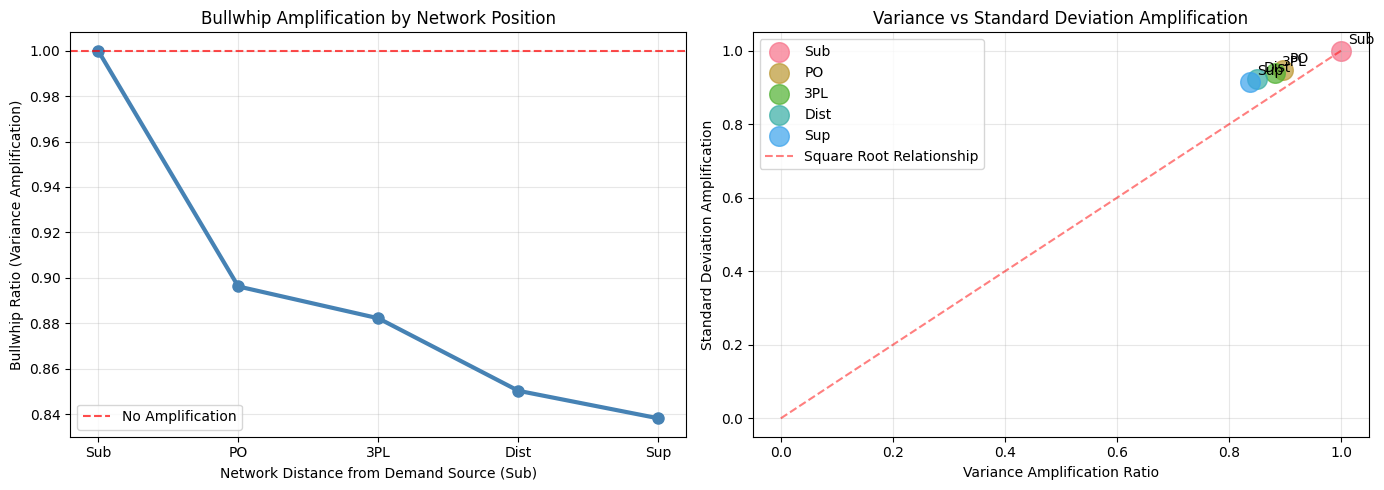

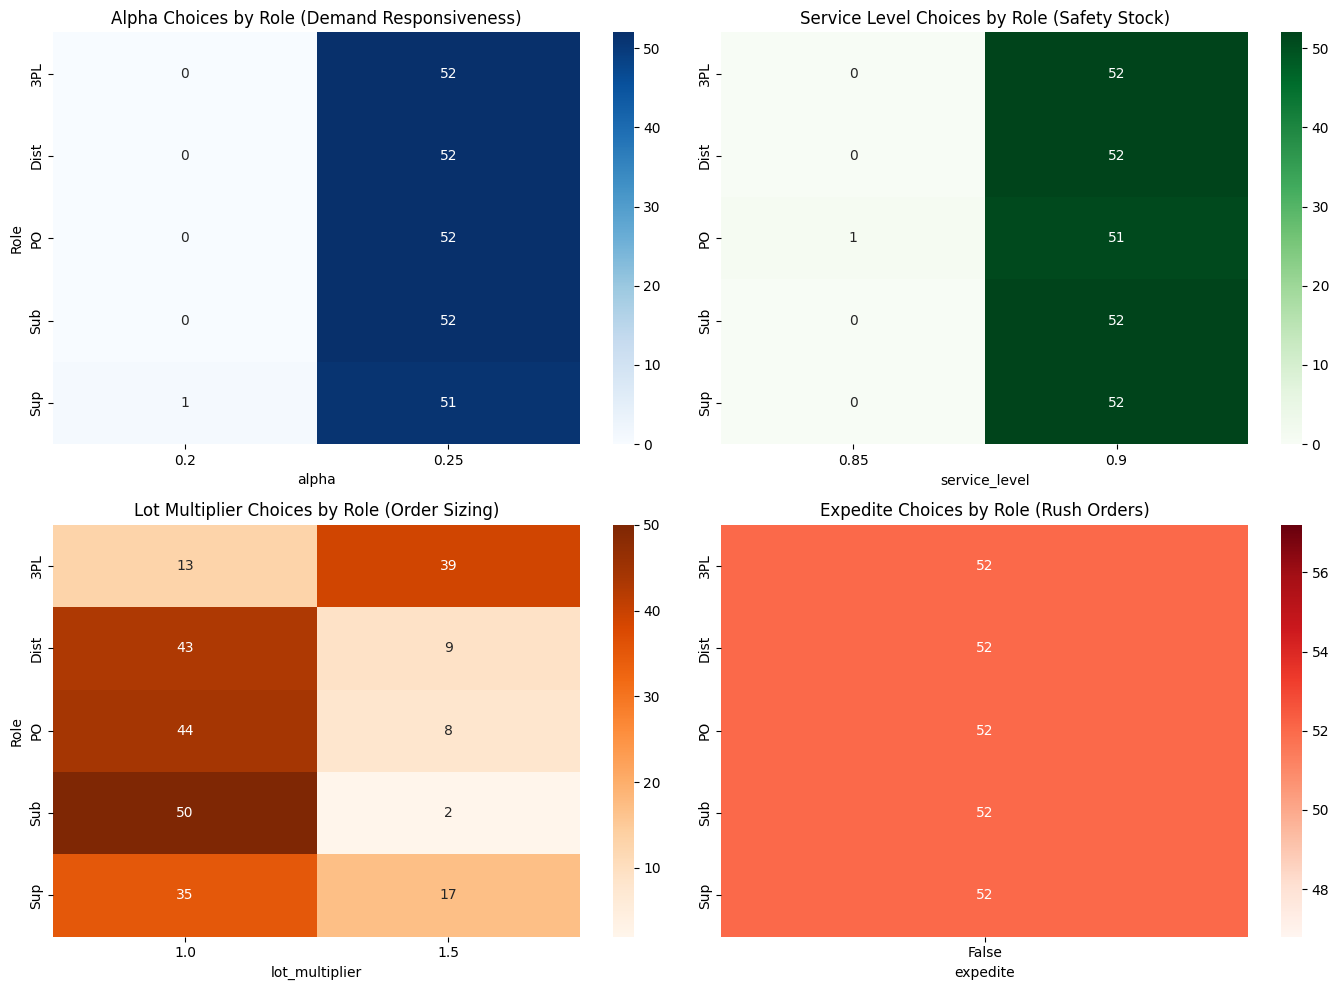

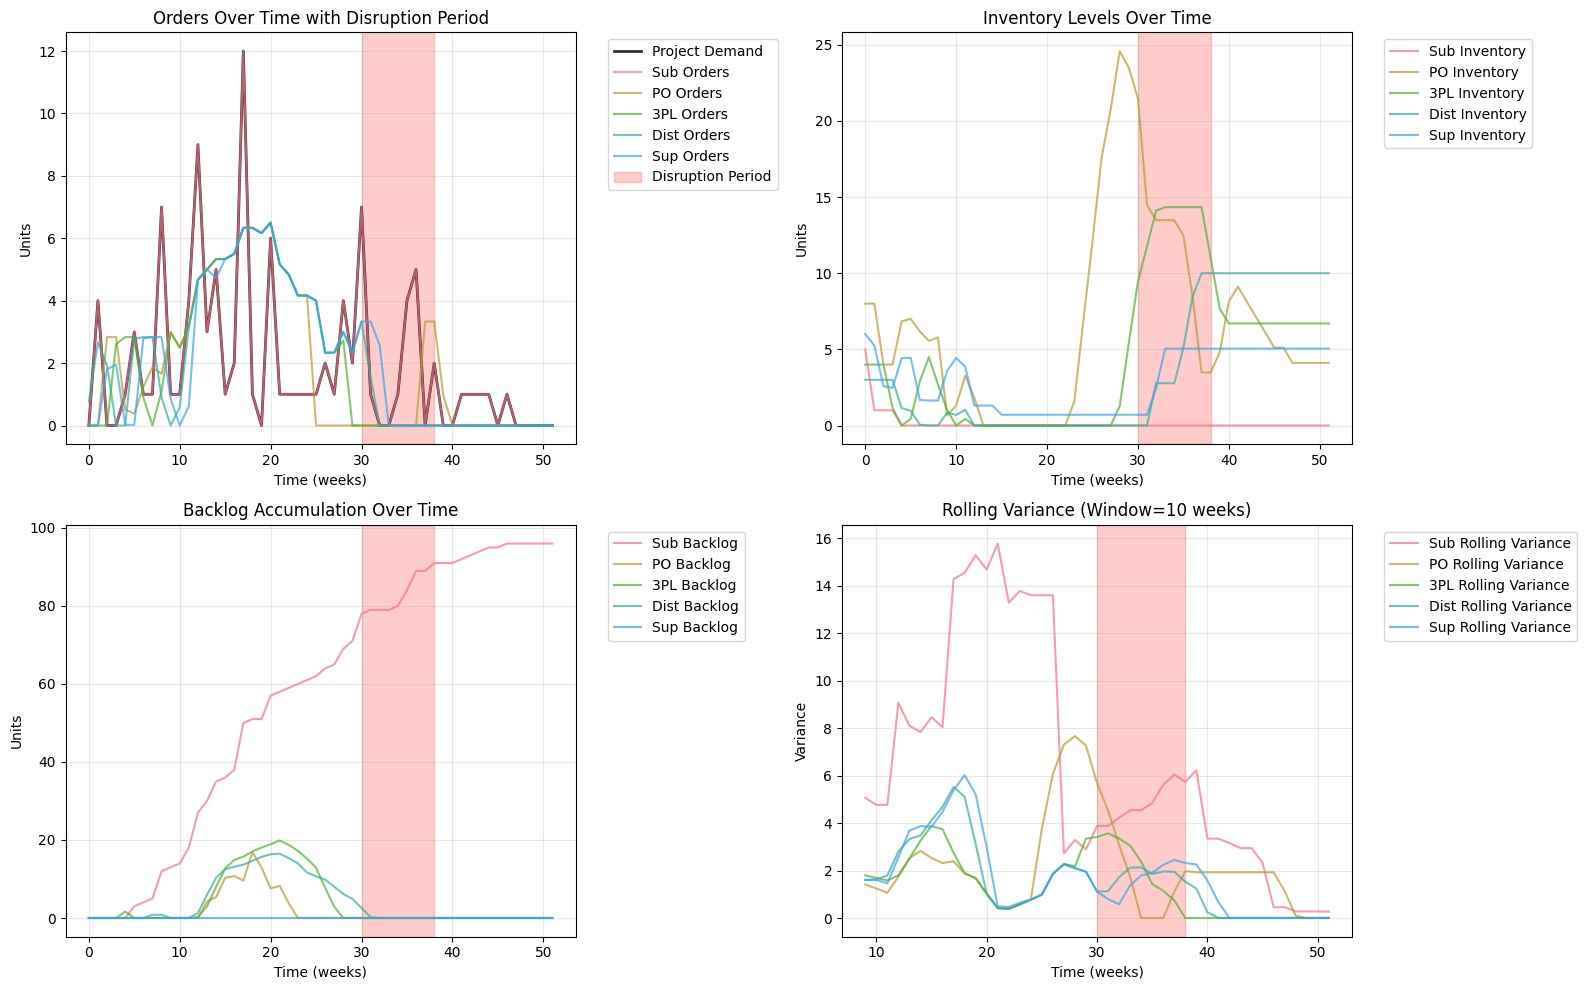

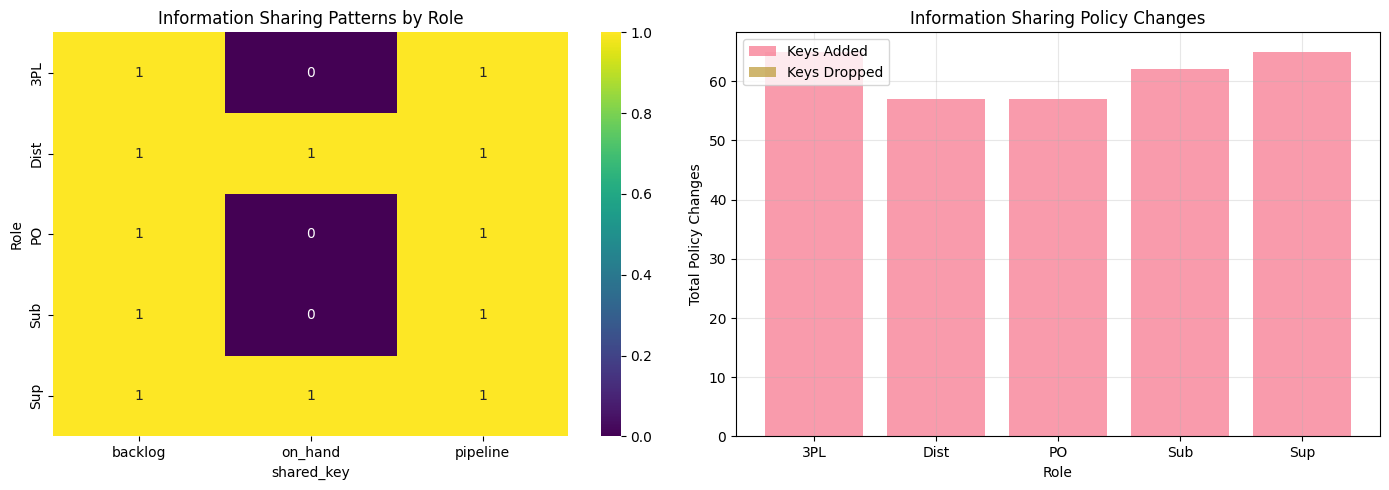

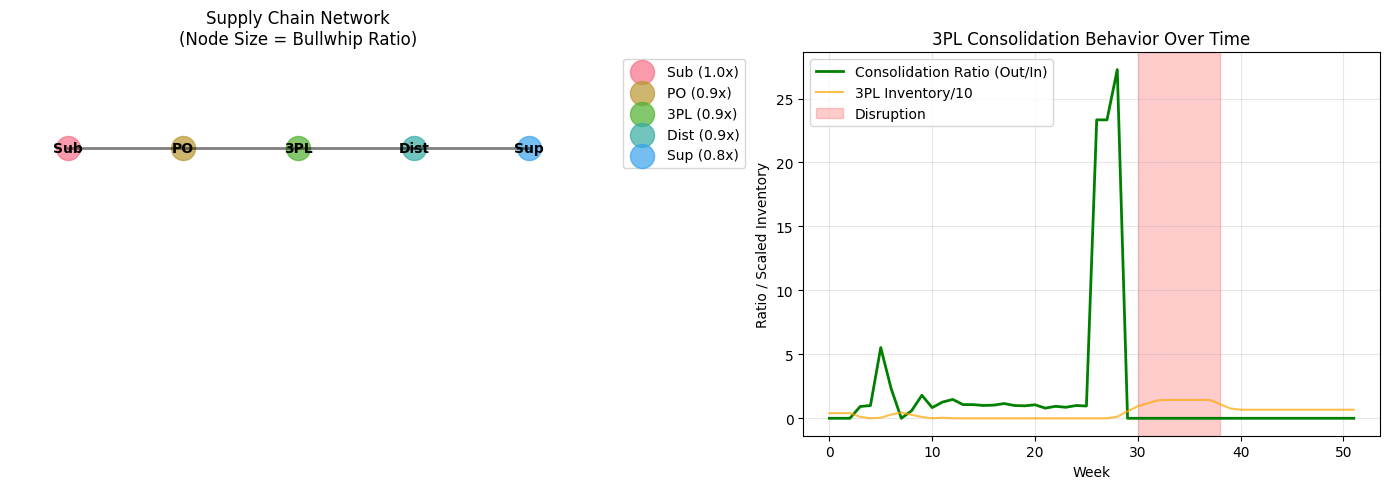

/tmp/ipython-input-1983328855.py:220: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([role_alphas[role] for role in roles_ordered], labels=roles_ordered)


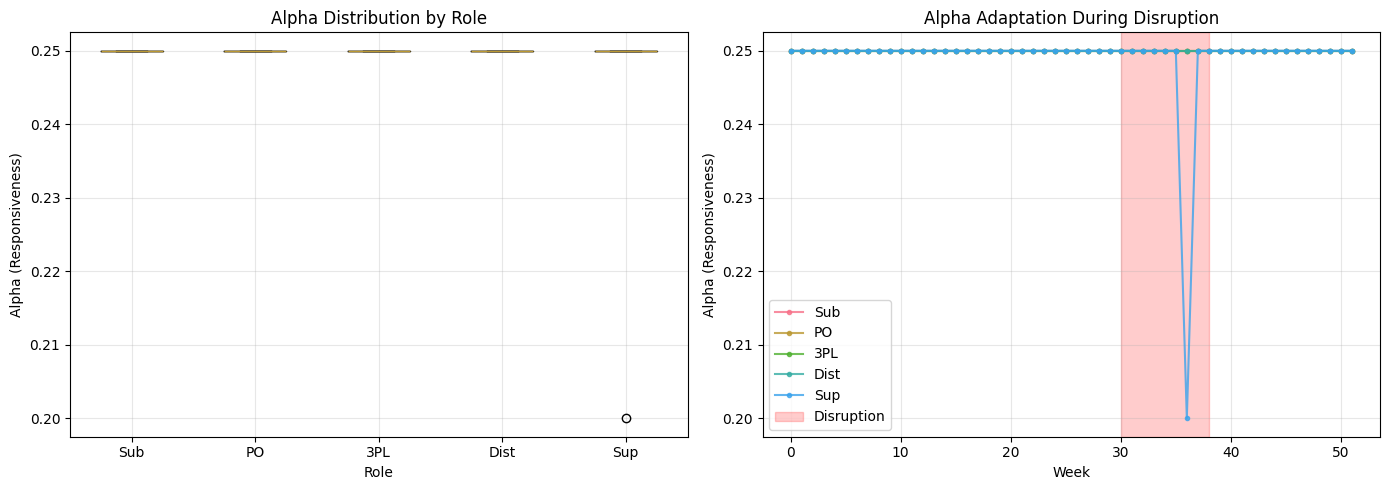

In [ ]:
# ===== Comprehensive Visualizations for Construction Supply Chain Research =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# Set style for publication-quality plots
plt.style.use('default')
sns.set_palette("husl")

# 1) BULLWHIP CASCADE ANALYSIS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bullwhip ratios with network distance - updated for 6-role chain
roles_ordered = ["Sub", "PO", "3PL", "Dist", "Sup"]
bullwhip_values = [df_kpi[df_kpi["role"] == r]["bullwhip_ratio_var"].iloc[0] for r in roles_ordered]
network_distances = [0, 1, 2, 3, 4]  # Distance from Sub (demand source)

ax1.plot(network_distances, bullwhip_values, 'o-', linewidth=3, markersize=8, color='steelblue')
ax1.set_xlabel('Network Distance from Demand Source (Sub)')
ax1.set_ylabel('Bullwhip Ratio (Variance Amplification)')
ax1.set_title('Bullwhip Amplification by Network Position')
ax1.set_xticks(network_distances)
ax1.set_xticklabels(roles_ordered)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='No Amplification')
ax1.legend()

# Mean vs Standard Deviation scatter
for i, role in enumerate(roles_ordered):
   row = df_kpi[df_kpi["role"] == role].iloc[0]
   ax2.scatter(row["bullwhip_ratio_var"], row["amplification_std"],
              s=200, alpha=0.7, label=role)
   ax2.annotate(role, (row["bullwhip_ratio_var"], row["amplification_std"]),
               xytext=(5, 5), textcoords='offset points')

ax2.set_xlabel('Variance Amplification Ratio')
ax2.set_ylabel('Standard Deviation Amplification')
ax2.set_title('Variance vs Standard Deviation Amplification')
ax2.grid(True, alpha=0.3)
ax2.plot([0, max(bullwhip_values)], [0, max(bullwhip_values)**0.5], 'r--', alpha=0.5, label='Square Root Relationship')
ax2.legend()

plt.tight_layout()
plt.show()

# 2) COEFFICIENT CHOICE HEATMAP BY ROLE
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Alpha choices
alpha_pivot = alpha_dist.pivot(index="role", columns="alpha", values="count").fillna(0).astype(int)
sns.heatmap(alpha_pivot, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Alpha Choices by Role (Demand Responsiveness)')
ax1.set_ylabel('Role')

# Service level choices
sl_pivot = sl_dist.pivot(index="role", columns="service_level", values="count").fillna(0).astype(int)
sns.heatmap(sl_pivot, annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('Service Level Choices by Role (Safety Stock)')
ax2.set_ylabel('')

# Lot multiplier choices
lot_pivot = lot_dist.pivot(index="role", columns="lot_multiplier", values="count").fillna(0).astype(int)
sns.heatmap(lot_pivot, annot=True, fmt='d', cmap='Oranges', ax=ax3)
ax3.set_title('Lot Multiplier Choices by Role (Order Sizing)')
ax3.set_ylabel('Role')

# Expedite choices
exp_pivot = exp_dist.pivot(index="role", columns="expedite", values="count").fillna(0).astype(int)
sns.heatmap(exp_pivot, annot=True, fmt='d', cmap='Reds', ax=ax4)
ax4.set_title('Expedite Choices by Role (Rush Orders)')
ax4.set_ylabel('')

plt.tight_layout()
plt.show()

# 3) TIME SERIES DECOMPOSITION WITH DISRUPTION
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))

t_idx = np.arange(len(customerDemand))
disruption_start = 30  # Week when disruption hits
disruption_end = 38    # Duration of 8 weeks

# Orders over time with disruption marker
ax1.plot(t_idx, customerDemand, 'k-', linewidth=2, label='Project Demand', alpha=0.8)
for role in ["Sub", "PO", "3PL", "Dist", "Sup"]:
   ax1.plot(t_idx, hist_roles["orders_out"][role], label=f'{role} Orders', alpha=0.7)
ax1.axvspan(disruption_start, disruption_end, alpha=0.2, color='red', label='Disruption Period')
ax1.set_title('Orders Over Time with Disruption Period')
ax1.set_xlabel('Time (weeks)')
ax1.set_ylabel('Units')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# Inventory levels over time
for role in ["Sub", "PO", "3PL", "Dist", "Sup"]:
   ax2.plot(t_idx, hist_roles["on_hand"][role], label=f'{role} Inventory', alpha=0.7)
ax2.axvspan(disruption_start, disruption_end, alpha=0.2, color='red')
ax2.set_title('Inventory Levels Over Time')
ax2.set_xlabel('Time (weeks)')
ax2.set_ylabel('Units')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

# Backlog accumulation
for role in ["Sub", "PO", "3PL", "Dist", "Sup"]:
   ax3.plot(t_idx, hist_roles["backlog"][role], label=f'{role} Backlog', alpha=0.7)
ax3.axvspan(disruption_start, disruption_end, alpha=0.2, color='red')
ax3.set_title('Backlog Accumulation Over Time')
ax3.set_xlabel('Time (weeks)')
ax3.set_ylabel('Units')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.grid(True, alpha=0.3)

# Rolling variance (bullwhip over time)
window = 10
for role in ["Sub", "PO", "3PL", "Dist", "Sup"]:
   rolling_var = pd.Series(hist_roles["orders_out"][role]).rolling(window).var()
   ax4.plot(t_idx, rolling_var, label=f'{role} Rolling Variance', alpha=0.7)
ax4.axvspan(disruption_start, disruption_end, alpha=0.2, color='red')
ax4.set_title(f'Rolling Variance (Window={window} weeks)')
ax4.set_xlabel('Time (weeks)')
ax4.set_ylabel('Variance')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4) INFORMATION SHARING ANALYSIS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Current sharing policy by role
sharing_data = []
for role in ROLES:
   for key in current_share[role]:
       sharing_data.append({"role": role, "shared_key": key})
sharing_df = pd.DataFrame(sharing_data)

if not sharing_df.empty:
   sharing_counts = sharing_df.groupby(["role", "shared_key"]).size().reset_index(name="count")
   sharing_pivot = sharing_counts.pivot(index="role", columns="shared_key", values="count").fillna(0).astype(int)
   sns.heatmap(sharing_pivot, annot=True, fmt='d', cmap='viridis', ax=ax1)
ax1.set_title('Information Sharing Patterns by Role')
ax1.set_ylabel('Role')

# Sharing policy changes over time
ax2.bar(df_policy["role"], df_policy["share_add_total"], alpha=0.7, label='Keys Added')
ax2.bar(df_policy["role"], df_policy["share_drop_total"], alpha=0.7, label='Keys Dropped')
ax2.set_title('Information Sharing Policy Changes')
ax2.set_xlabel('Role')
ax2.set_ylabel('Total Policy Changes')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5) NETWORK STRUCTURE VISUALIZATION
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Position nodes for 6-role network
positions = {"Sub": (0, 1), "PO": (1, 1), "3PL": (2, 1), "Dist": (3, 1), "Sup": (4, 1)}
bullwhip_dict = dict(zip(roles_ordered, bullwhip_values))

# Draw network
for role, (x, y) in positions.items():
   if role in bullwhip_dict:
       size = max(300, bullwhip_dict[role] * 50)  # Scale node size by bullwhip
       ax1.scatter(x, y, s=size, alpha=0.7, label=f'{role} ({bullwhip_dict[role]:.1f}x)')
       ax1.annotate(role, (x, y), ha='center', va='center', fontweight='bold')

# Draw connections for 6-role chain
connections = [("Sub", "PO"), ("PO", "3PL"), ("3PL", "Dist"), ("Dist", "Sup")]
for start, end in connections:
   x1, y1 = positions[start]
   x2, y2 = positions[end]
   ax1.plot([x1, x2], [y1, y2], 'k-', alpha=0.5, linewidth=2)

ax1.set_title('Supply Chain Network\n(Node Size = Bullwhip Ratio)')
ax1.set_xlim(-0.5, 4.5)  # Extended for 6 nodes
ax1.set_ylim(-0.5, 1.5)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.axis('off')

# 3PL Consolidation Analysis
consolidation_data = []
for t in range(len(customerDemand)):
   consolidation_data.append({
       "week": t,
       "3PL_in": hist_roles["orders_in"]["3PL"][t],
       "3PL_out": hist_roles["orders_out"]["3PL"][t],
       "3PL_inventory": hist_roles["on_hand"]["3PL"][t],
       "consolidation_ratio": hist_roles["orders_out"]["3PL"][t] / max(hist_roles["orders_in"]["3PL"][t], 0.1)
   })

consol_df = pd.DataFrame(consolidation_data)
ax2.plot(consol_df["week"], consol_df["consolidation_ratio"], 'g-', linewidth=2, label='Consolidation Ratio (Out/In)')
ax2.plot(consol_df["week"], consol_df["3PL_inventory"]/10, 'orange', alpha=0.7, label='3PL Inventory/10')
ax2.axvspan(disruption_start, disruption_end, alpha=0.2, color='red', label='Disruption')
ax2.set_title('3PL Consolidation Behavior Over Time')
ax2.set_xlabel('Week')
ax2.set_ylabel('Ratio / Scaled Inventory')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6) NEW: ROLE-SPECIFIC ALPHA STRATEGIES
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Alpha distribution by role
role_alphas = {}
for role in roles_ordered:
   if role in coeff_logs:
       role_alphas[role] = [c["alpha"] for c in coeff_logs[role]]

ax1.boxplot([role_alphas[role] for role in roles_ordered], labels=roles_ordered)
ax1.set_title('Alpha Distribution by Role')
ax1.set_ylabel('Alpha (Responsiveness)')
ax1.set_xlabel('Role')
ax1.grid(True, alpha=0.3)

# Alpha evolution during disruption
for role in roles_ordered:
   if role in coeff_logs:
       times = [c["t"] for c in coeff_logs[role]]
       alphas = [c["alpha"] for c in coeff_logs[role]]
       ax2.plot(times, alphas, 'o-', label=role, alpha=0.8, markersize=3)

ax2.axvspan(disruption_start, disruption_end, alpha=0.2, color='red', label='Disruption')
ax2.set_title('Alpha Adaptation During Disruption')
ax2.set_xlabel('Week')
ax2.set_ylabel('Alpha (Responsiveness)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()